In [1]:
import kagglehub
import os

path = kagglehub.competition_download('house-prices-advanced-regression-techniques')

os.listdir(path)

100%|██████████| 199k/199k [00:00<00:00, 718kB/s]

Extracting files...


['test.csv', 'sample_submission.csv', 'train.csv', 'data_description.txt']

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
train_df = pd.read_csv(os.path.join(path, "train.csv"))
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
train_df.shape

(1460, 81)

In [24]:
columns_null = []

for column in train_df.columns:
  if train_df[column].isnull().sum() > 0:
    columns_null.append((column, train_df[column].isnull().sum()))

In [25]:
columns_null

[('LotFrontage', np.int64(259)),
 ('Alley', np.int64(1369)),
 ('MasVnrType', np.int64(872)),
 ('MasVnrArea', np.int64(8)),
 ('BsmtQual', np.int64(37)),
 ('BsmtCond', np.int64(37)),
 ('BsmtExposure', np.int64(38)),
 ('BsmtFinType1', np.int64(37)),
 ('BsmtFinType2', np.int64(38)),
 ('Electrical', np.int64(1)),
 ('FireplaceQu', np.int64(690)),
 ('GarageType', np.int64(81)),
 ('GarageYrBlt', np.int64(81)),
 ('GarageFinish', np.int64(81)),
 ('GarageQual', np.int64(81)),
 ('GarageCond', np.int64(81)),
 ('PoolQC', np.int64(1453)),
 ('Fence', np.int64(1179)),
 ('MiscFeature', np.int64(1406))]

Many features in the dataset have a lot of null values. This however just indicates that the particular feature is just not available for the plot. For instance if Alley is NA, it means that the property doesn't have access to an alley.

In [27]:
train_df["SalePrice"].describe()

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


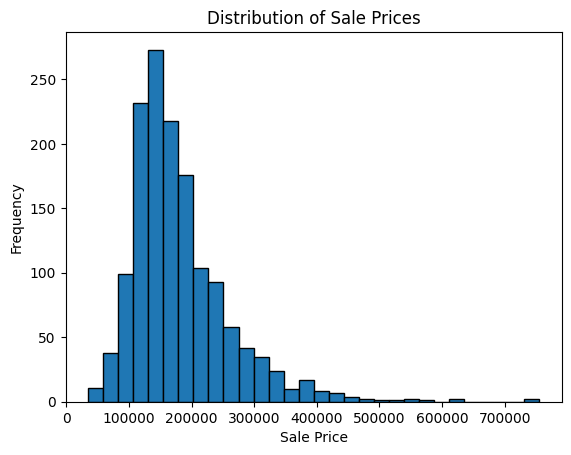

In [28]:
plt.hist(train_df['SalePrice'], bins=30, edgecolor='black')

plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.title('Distribution of Sale Prices')


plt.show()

In [29]:
train_df["SalePrice"].skew()

np.float64(1.8828757597682129)

The target variable has a right skew as expected with house prices, so I'll log(1+x) transform the target variable. This helps linear models predict better as they require normal distributions, and will also prevent MSE loss from weighting the errors unevenly

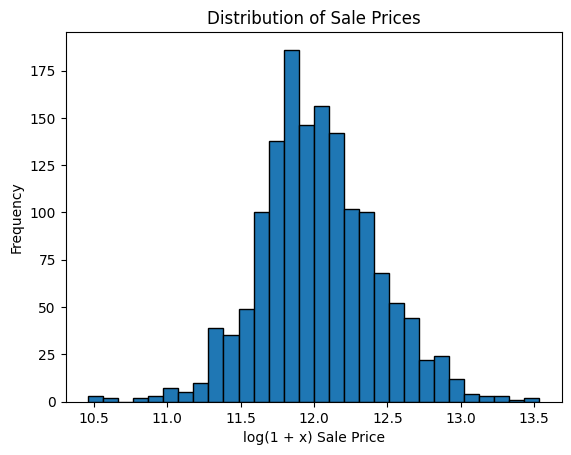

In [31]:
plt.hist(np.log1p(train_df['SalePrice']), bins=30, edgecolor='black')

plt.xlabel('log(1 + x) Sale Price')
plt.ylabel('Frequency')
plt.title('Distribution of Sale Prices')

plt.show()

In [32]:
np.log1p(train_df['SalePrice']).skew()

np.float64(0.12134661989685333)

In [47]:
numerical_cols = [col for col in train_df.columns if train_df[col].dtype in ["int64", "float64", "int32", "float32"] and col != "Id" and col != "SalePrice"]

In [48]:
[]

['MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold']

In [49]:
train_df["OverallQual"].describe()

,OverallQual
count,1460.000000
mean,6.099315
std,1.382997
min,1.000000
25%,5.000000
50%,6.000000
75%,7.000000
max,10.000000


In [52]:
train_df[numerical_cols].nunique().sort_values()

,0
HalfBath,3
BsmtHalfBath,3
FullBath,4
BsmtFullBath,4
Fireplaces,4
KitchenAbvGr,4
GarageCars,5
YrSold,5
PoolArea,8
BedroomAbvGr,8


In [57]:
numerical_data_cats = [col for col in numerical_cols if train_df[col].nunique() <= 15 and col != "PoolArea"]
numerical_data_continuous = [col for col in numerical_cols if col not in numerical_data_cats]

In [58]:
numerical_data_cats

['MSSubClass',
 'OverallQual',
 'OverallCond',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageCars',
 'MoSold',
 'YrSold']

Everything in numerical_data_cats is ordinal barring MSSubClass and Month sold. Month sold could be seasonal with buying patterns within a year fluctuating and having no real order, however year sold is ordinal as a house sold in 2026 will be more expensive, more often than not, than a house sold in 2006

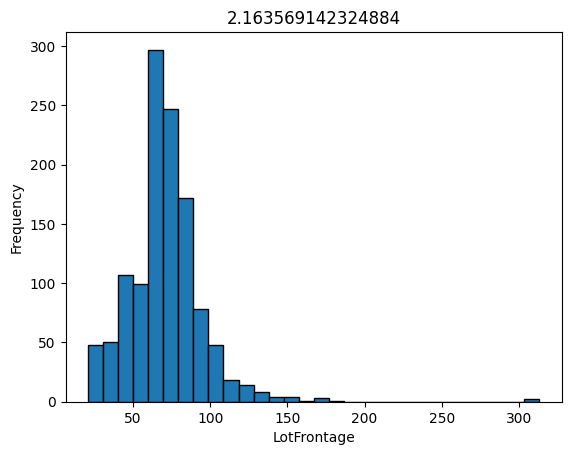

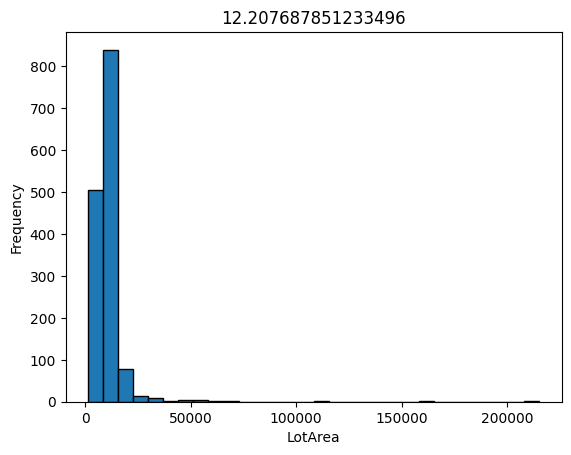

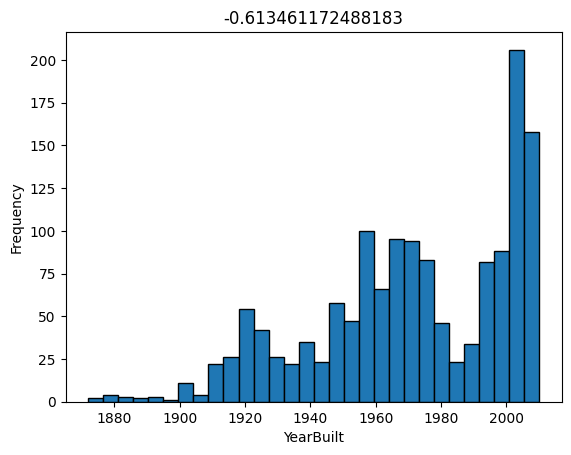

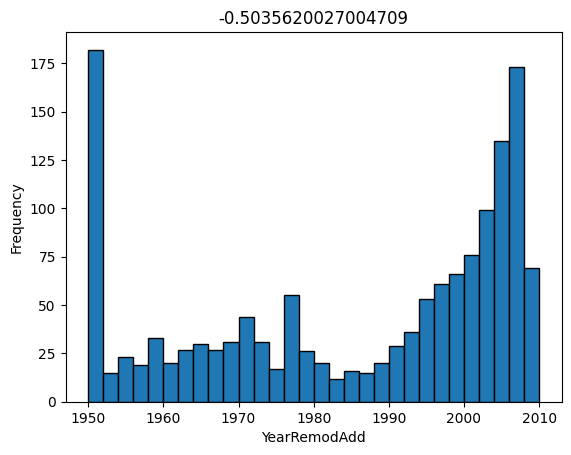

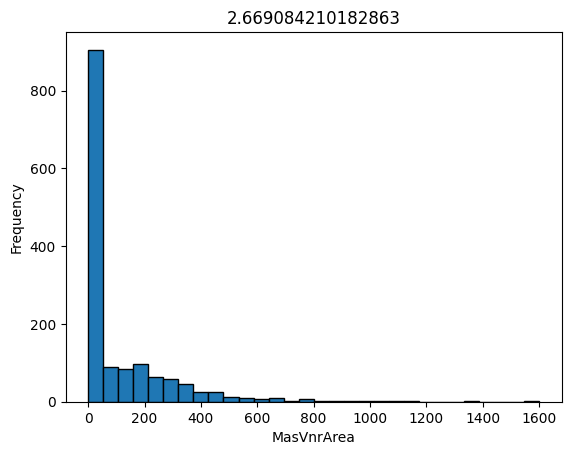

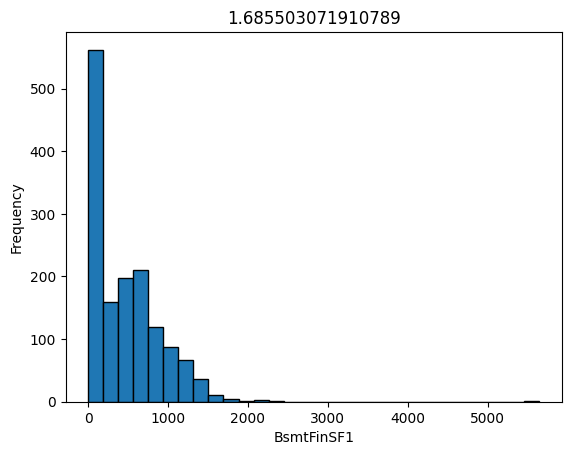

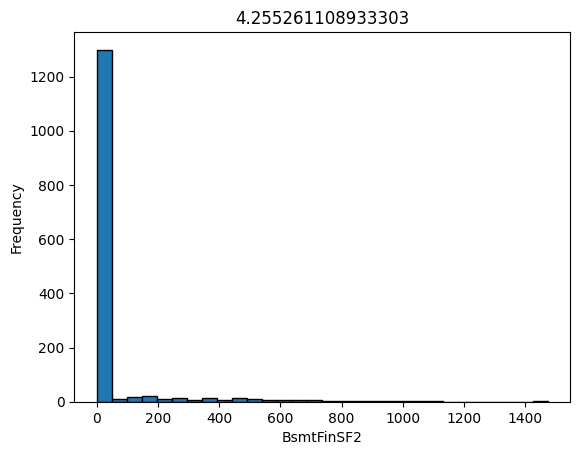

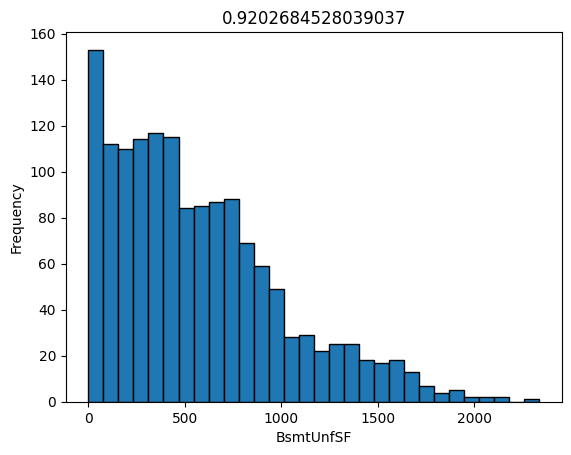

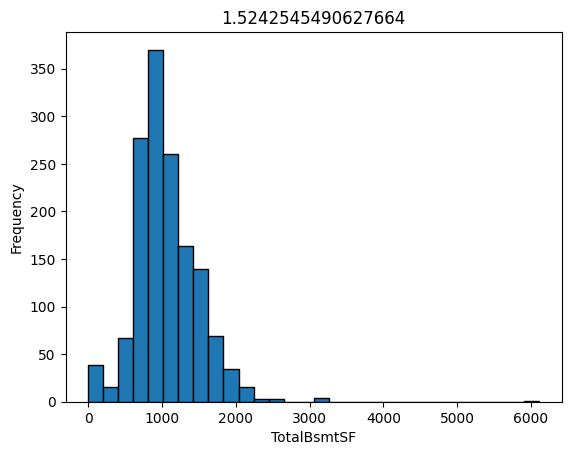

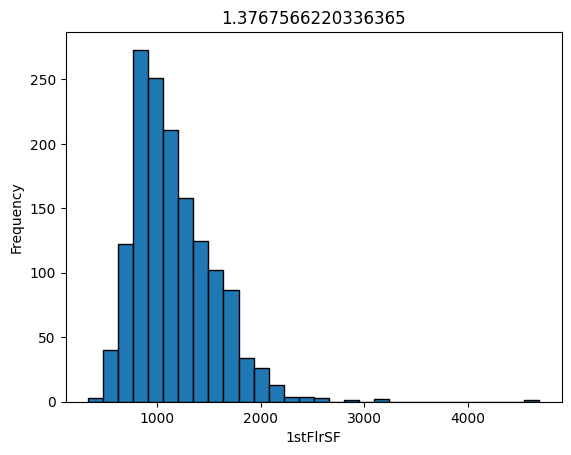

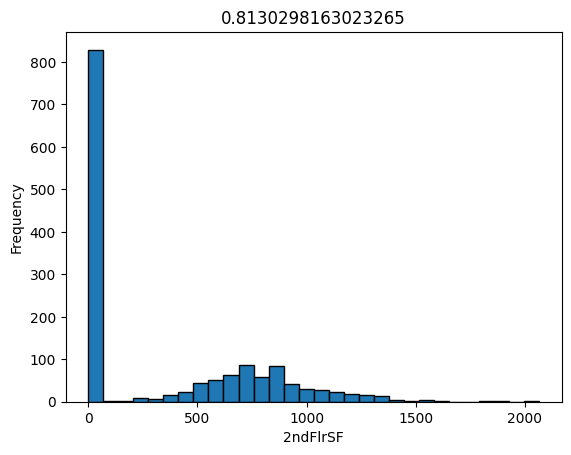

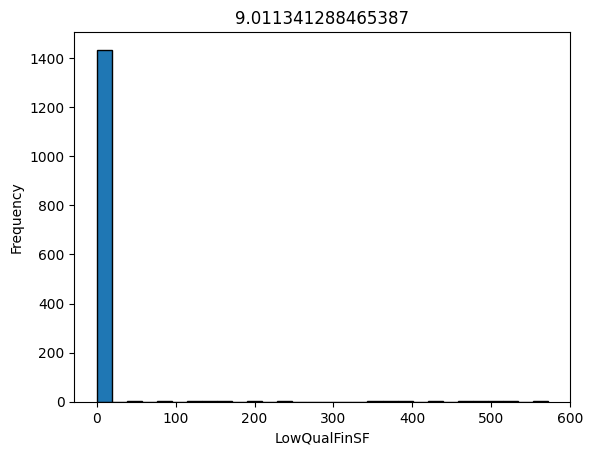

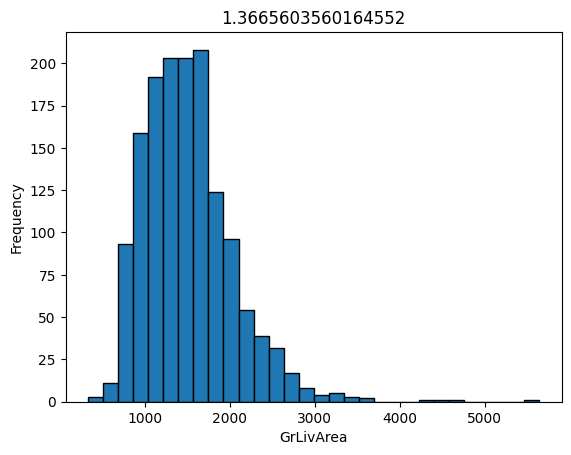

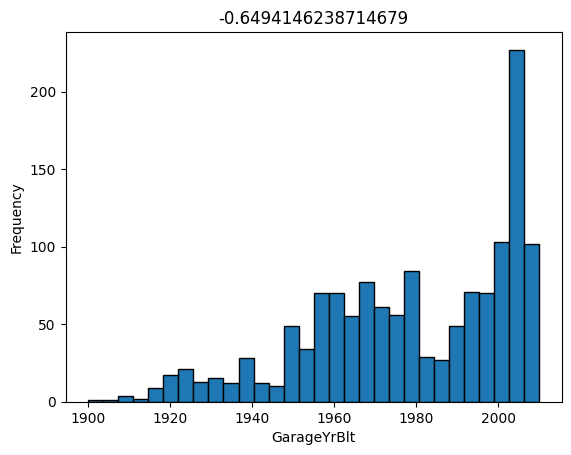

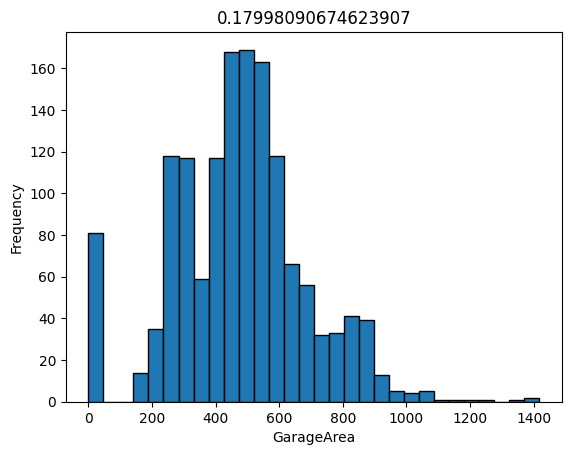

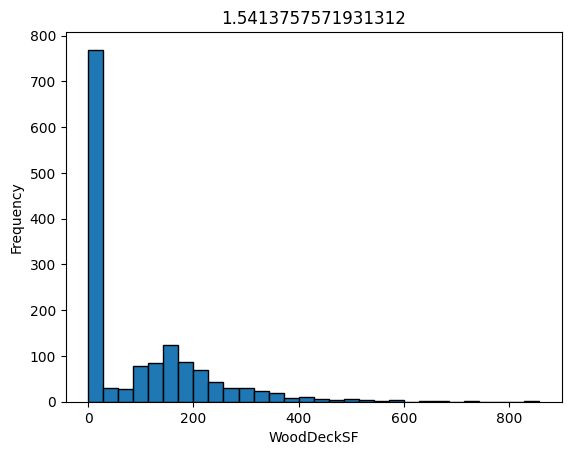

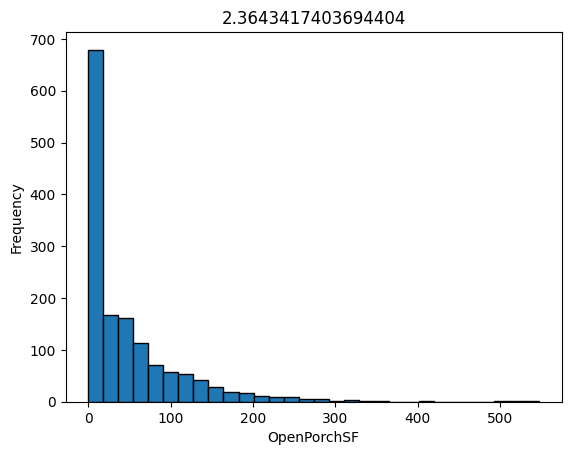

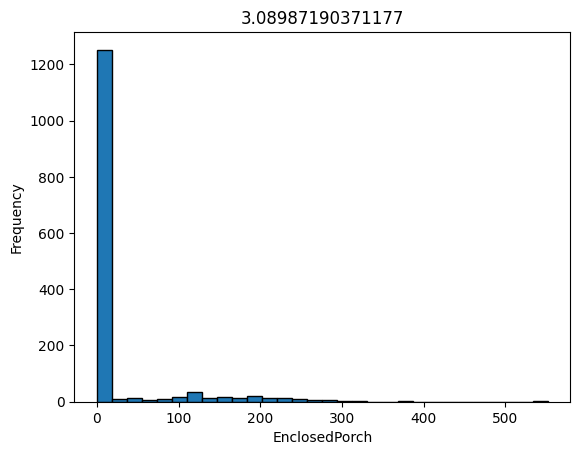

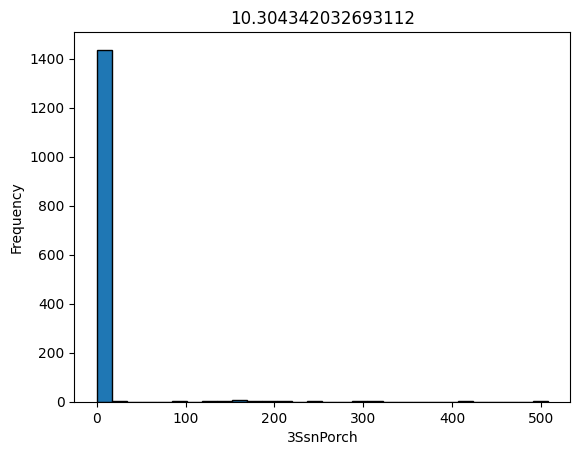

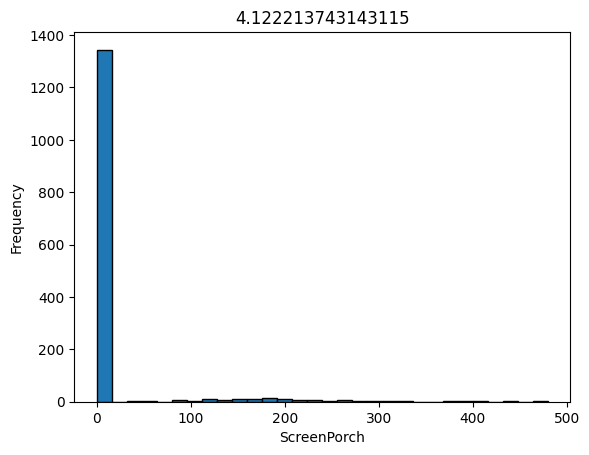

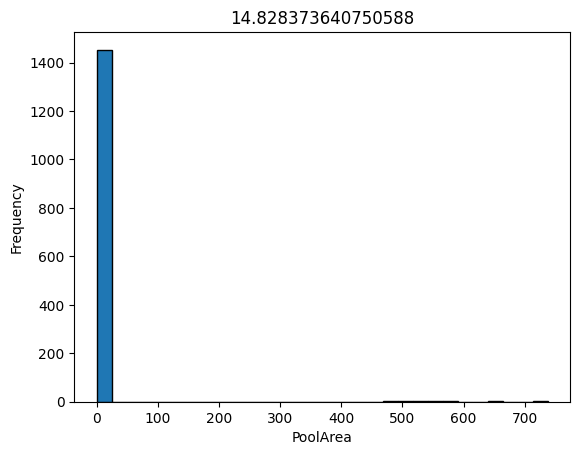

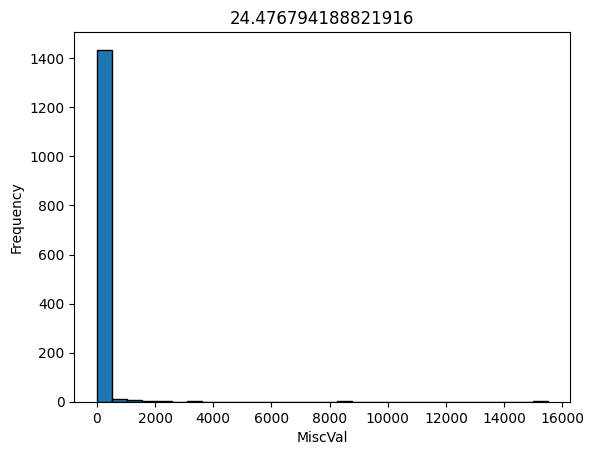

In [61]:
#### plotting a histogram for all the continuous numerical columns

skew_list = []

for col in numerical_data_continuous:
  plt.hist(train_df[col], bins=30, edgecolor="black")
  plt.xlabel(col)
  plt.ylabel("Frequency")
  skew_list.append((col, train_df[col].skew()))
  plt.title(train_df[col].skew())
  plt.show()
  print("\n\n")

Columns like MiscVal, PoolArea, ScreenPorch, 3SsnPorch, EnclosedPorch, are sparse and have most of their values concentrated in 0. Converting these to a binary flag would make a lot of sense


Additionally columns like GRLivArea, 1stFloorSf, TotalBsmtSF, BSMTUnfSF, BSMTfinsf1 etc are skewed and doing a log transform might help.

Columns like 2ndFloorSF and WoodDeckSF, have a lot of values at 0 and seem to have a distribution after that, so might be worth splitting those into two cols, as a binary flag and a log transformed numerical one


#Data Cleaning

Before transforming these columns, I will clean the dataset first

In [70]:
train_df[categorical_cols].isnull().sum()[train_df[categorical_cols].isnull().sum() > 0].sort_values()

,0
Electrical,1
BsmtCond,37
BsmtFinType1,37
BsmtQual,37
BsmtExposure,38
BsmtFinType2,38
GarageFinish,81
GarageType,81
GarageQual,81
GarageCond,81


In [72]:
train_df["BsmtExposure"].unique()

array(['No', 'Gd', 'Mn', 'Av', nan], dtype=object)

In [75]:
null_categorical = [col for col in train_df.columns if train_df[col].isnull().sum() > 0]
null_categorical

['LotFrontage',
 'Alley',
 'MasVnrType',
 'MasVnrArea',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'FireplaceQu',
 'GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PoolQC',
 'Fence',
 'MiscFeature']

In [77]:
numerical_nulls = [col for col in null_categorical if train_df[col].dtype in ["int64", "float64", "int32", "float32"]]
numerical_nulls

['LotFrontage', 'MasVnrArea', 'GarageYrBlt']

Replacing null's with None in the categorical columns

In [86]:
def cleaning_categorical(df):

  ##For the test set, we have to impute the electrical value, otherwise we won't have a prediction to submit for that row
  df = df.dropna(subset=["Electrical"])
  for col in null_categorical:
    if col not in numerical_nulls:
      df[col] = df[col].fillna("None")

  df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)

  df["MasVnrArea"] = df["MasVnrArea"].fillna(0)

  return df

In [87]:
neighborhood_medians = train_df.groupby('Neighborhood')['LotFrontage'].median()

def impute_lotfrontage(df, neighborhood_medians):
    df['LotFrontage'] = df['LotFrontage'].fillna(df['Neighborhood'].map(neighborhood_medians))
    return df

In [84]:
train_df.isnull().sum().sort_values(ascending=False)

,0
PoolQC,1452
MiscFeature,1405
Alley,1368
Fence,1178
MasVnrType,871
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [90]:
def data_cleaning(df): ###Data cleaning orchestrator function
  df = cleaning_categorical(df)
  df = impute_lotfrontage(df, neighborhood_medians)
  return df

In [91]:
train_df = data_cleaning(train_df)

In [92]:
train_df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [94]:
def deriving_features(df):
  df["TotalSF"] = df["1stFlrSF"] + df["2ndFlrSF"] + df["TotalBsmtSF"]
  df['TotalBath'] = df['FullBath'] + (0.5 * df['HalfBath']) + df['BsmtFullBath'] + (0.5 * df['BsmtHalfBath'])
  df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
  df["YearSinceRemod"] = df["YrSold"] - df["YearRemodAdd"]
  return df

In [97]:
train_df = deriving_features(train_df)

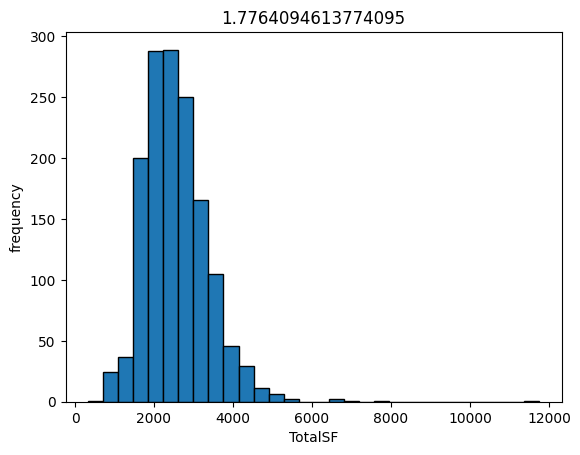

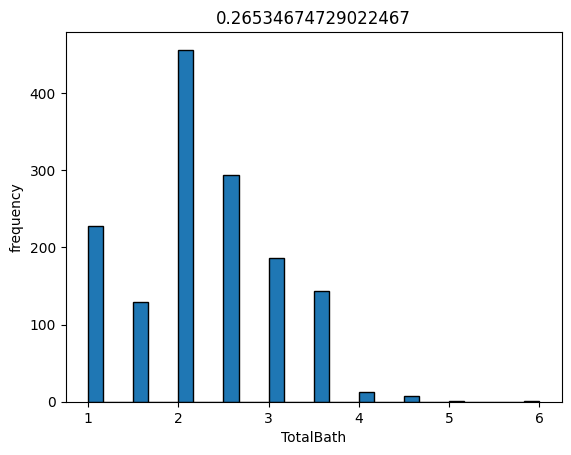

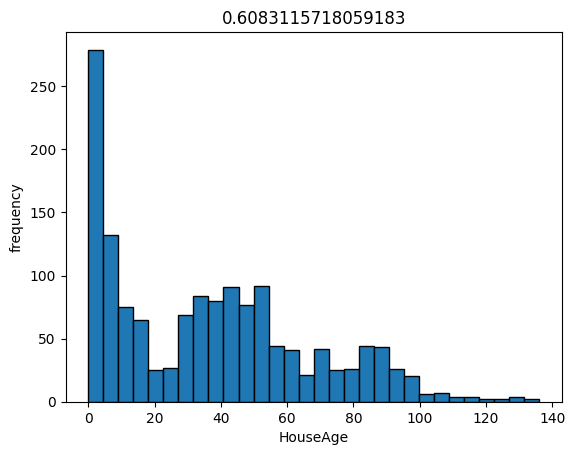

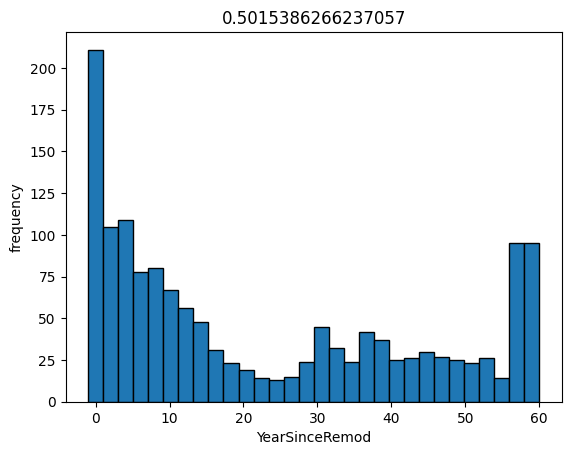

In [99]:
for col in ["TotalSF", "TotalBath", "HouseAge", "YearSinceRemod"]:
  plt.hist(train_df[col], bins=30, edgecolor="black")
  plt.xlabel(col)
  plt.ylabel("frequency")
  plt.title(train_df[col].skew())
  plt.show()

  print("\n\n")

In [103]:
log_features = [
    "LotFrontage",
    "LotArea",
    "MasVnrArea",
    "BsmtFinSF1",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "1stFlrSF",
    "GrLivArea",
    "GarageArea",
    "OpenPorchSF",
    "TotalSF"
]

In [105]:
train_df["SalePrice"] = np.log1p(train_df["SalePrice"])

In [104]:
def log_transform(df):
  for col in log_features:
    df[col] = np.log1p(df[col])

  return df

In [106]:
train_df = log_transform(train_df)

In [110]:
train_df = train_df.drop(columns=["Id"])

In [111]:
flag_only = ["MiscVal", "PoolArea", "ScreenPorch", "3SsnPorch", "EnclosedPorch"]

In [114]:
def flag_transform(df):
  for col in flag_only:
    df["Has" + col] = df[col] > 0

  df = df.drop(columns=flag_only)
  return df

In [116]:
train_df = flag_transform(train_df)

In [121]:
flag_with_skew = ["2ndFlrSF", "WoodDeckSF"]

In [122]:
def flag_log_transform(df):
  for col in flag_with_skew:
    df["Has" + col] = df[col] > 0

  for col in flag_with_skew:
    df[col] = np.log1p(df[col])

  return df

In [124]:
train_df = flag_log_transform(train_df)

In [129]:
ordinal_mappings = {
    # Standard Quality and Condition Ratings
    "ExterQual": {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "ExterCond": {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "BsmtQual": {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "BsmtCond": {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "HeatingQC": {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "KitchenQual": {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "FireplaceQu": {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "GarageQual": {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "GarageCond": {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "PoolQC": {"None": 0, "Fa": 1, "TA": 2, "Gd": 3, "Ex": 4},

    # Basement Specifics
    "BsmtExposure": {"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4},
    "BsmtFinType1": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "BsmtFinType2": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},

    # Garage Finish
    "GarageFinish": {"None": 0, "Unf": 1, "RFn": 2, "Fin": 3},

    # Lot and Land Features
    "LotShape": {"IR3": 1, "IR2": 2, "IR1": 3, "Reg": 4},
    "LandSlope": {"Sev": 1, "Mod": 2, "Gtl": 3},

    # Access and Driveway
    "Street": {"Grvl": 0, "Pave": 1},
    "Alley": {"None": 0, "Grvl": 1, "Pave": 2},
    "PavedDrive": {"N": 0, "P": 1, "Y": 2},

    # Utilities and Systems
    "Utilities": {"ELO": 1, "NoSeWa": 2, "NoSewr": 3, "AllPub": 4},
    "CentralAir": {"N": 0, "Y": 1},

    # Additional Features
    "Fence": {"None": 0, "MnWw": 1, "GdWo": 2, "MnPrv": 3, "GdPrv": 4},
    "Functional": {"Sal": 1, "Sev": 2, "Maj2": 3, "Maj1": 4, "Mod": 5, "Min2": 6, "Min1": 7, "Typ": 8}
}

In [131]:
def apply_ordinal_mappings(df):

  for col in ordinal_mappings:
    df[col] = df[col].map(ordinal_mappings[col])

  return df

In [132]:
train_df = apply_ordinal_mappings(train_df)

In [136]:
nominal_cat_columns = [
    'MSSubClass', 'MSZoning', 'Alley', 'LandContour', 'LotConfig',
    'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
    'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
    'Foundation', 'Heating', 'Electrical', 'GarageType', 'MiscFeature',
    'SaleType', 'SaleCondition'
]

In [138]:
for col in nominal_cat_columns:
  print(col, train_df[col].nunique())

MSSubClass 15
MSZoning 5
Alley 3
LandContour 4
LotConfig 5
Neighborhood 25
Condition1 9
Condition2 8
BldgType 5
HouseStyle 8
RoofStyle 6
RoofMatl 8
Exterior1st 15
Exterior2nd 16
MasVnrType 4
Foundation 6
Heating 6
Electrical 5
GarageType 7
MiscFeature 5
SaleType 9
SaleCondition 6


In [141]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from category_encoders import CountEncoder

In [143]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from category_encoders import CountEncoder

# 1. Dynamically split columns based on training set cardinality
ohe_cols = [col for col in nominal_cat_columns if train_df[col].nunique() < 5]
freq_cols = [col for col in nominal_cat_columns if train_df[col].nunique() >= 5]

# 2. Build the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        (
            'ohe',
            OneHotEncoder(handle_unknown='ignore', sparse_output=False),
            ohe_cols
        ),
        (
            'freq',
            CountEncoder(handle_unknown=1, min_group_size=1),
            freq_cols
        )
    ],
    remainder='passthrough' # Keeps numerical or unlisted columns unchanged
)

# 3. Fit on training data, transform both train and test sets
train_df = pd.DataFrame(
    preprocessor.fit_transform(train_df),
    columns=preprocessor.get_feature_names_out()
)

In [146]:
train_df.columns

Index(['ohe__Alley_0', 'ohe__Alley_1', 'ohe__Alley_2', 'ohe__LandContour_Bnk',
       'ohe__LandContour_HLS', 'ohe__LandContour_Low', 'ohe__LandContour_Lvl',
       'ohe__MasVnrType_BrkCmn', 'ohe__MasVnrType_BrkFace',
       'ohe__MasVnrType_None', 'ohe__MasVnrType_Stone', 'freq__MSSubClass',
       'freq__MSZoning', 'freq__LotConfig', 'freq__Neighborhood',
       'freq__Condition1', 'freq__Condition2', 'freq__BldgType',
       'freq__HouseStyle', 'freq__RoofStyle', 'freq__RoofMatl',
       'freq__Exterior1st', 'freq__Exterior2nd', 'freq__Foundation',
       'freq__Heating', 'freq__Electrical', 'freq__GarageType',
       'freq__MiscFeature', 'freq__SaleType', 'freq__SaleCondition',
       'remainder__LotFrontage', 'remainder__LotArea', 'remainder__Street',
       'remainder__LotShape', 'remainder__Utilities', 'remainder__LandSlope',
       'remainder__OverallQual', 'remainder__OverallCond',
       'remainder__YearBuilt', 'remainder__YearRemodAdd',
       'remainder__MasVnrArea', 'remai

In [147]:
def feature_transformation(df):
  df = deriving_features(df)
  df = log_transform(df)
  df = df.drop(columns=["Id"])
  df = flag_transform(df)
  df = flag_log_transform(df)
  df = apply_ordinal_mappings(df)
  df = pd.DataFrame(preprocessor.transform(df), columns=preprocessor.get_feature_names_out())
  return df

In [175]:
X = train_df.drop(columns=["remainder__SalePrice"])
y = train_df["remainder__SalePrice"]

In [176]:
X = X.astype("float")
y = y.astype("float")

In [177]:
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_val_score

In [178]:
base_model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [179]:
kf = KFold(n_splits=3, shuffle=True, random_state=42)

In [180]:
mse_scores = cross_val_score(
    base_model,
    X,
    y,
    cv=kf,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

rmse_scores = np.sqrt(-mse_scores)
print(f"Mean RMSE: {rmse_scores.mean():.4f}")

Mean RMSE: 0.1369


In [181]:
r2_scores = cross_val_score(
    base_model,
    X,
    y,
    cv=kf,
    scoring='r2',
    n_jobs=-1
)

print(f"Mean R-Squared: {r2_scores.mean():.4f}")
print(f"Standard Deviation: {r2_scores.std():.4f}")

Mean R-Squared: 0.8818
Standard Deviation: 0.0091


In [184]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

In [185]:
param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.2),       # Values between 0.01 and 0.21
    'subsample': uniform(0.6, 0.4),            # Values between 0.6 and 1.0
    'colsample_bytree': uniform(0.6, 0.4)      # Values between 0.6 and 1.0
}

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=50,                                 # Number of random combinations to try
    scoring='neg_mean_squared_error',
    cv=kf,                                     # Your existing 3-fold cross-validation
    verbose=1,                                 # Prints progress logs
    random_state=42,
    n_jobs=-1
)

random_search.fit(X, y)


print(f"Best Parameters: {random_search.best_params_}")

best_rmse = np.sqrt(-random_search.best_score_)
print(f"Best Cross-Validated RMSE: {best_rmse:.4f}")


best_model = random_search.best_estimator_

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters: {'colsample_bytree': np.float64(0.6036788206466518), 'learning_rate': np.float64(0.030294308573206426), 'max_depth': 5, 'n_estimators': 252, 'subsample': np.float64(0.6020246335384875)}
Best Cross-Validated RMSE: 0.1325


In [186]:
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge, LinearRegression

In [188]:
rf_param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(5, 20),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=50,
    scoring='neg_mean_squared_error',
    cv=kf,
    random_state=42,
    n_jobs=-1
)
rf_search.fit(X, y)
best_rf = rf_search.best_estimator_
print(f"Best RF RMSE: {np.sqrt(-rf_search.best_score_):.4f}")

Best RF RMSE: 0.1462


In [189]:
ridge_param_dist = {
    'alpha': uniform(0.1, 30.0)
}

ridge_search = RandomizedSearchCV(
    estimator=Ridge(random_state=42),
    param_distributions=ridge_param_dist,
    n_iter=30,
    scoring='neg_mean_squared_error',
    cv=kf,
    random_state=42,
    n_jobs=-1
)
ridge_search.fit(X, y)
best_ridge = ridge_search.best_estimator_
print(f"Best Ridge RMSE: {np.sqrt(-ridge_search.best_score_):.4f}")

Best Ridge RMSE: 0.1390


In [190]:
test_df = pd.read_csv(os.path.join(path, "test.csv"))

In [195]:
test_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [196]:
test_df = data_cleaning(test_df)

In [202]:
test_df.isnull().sum()[test_df.isnull().sum() > 0]

,0
MSZoning,4
Utilities,2
Exterior1st,1
Exterior2nd,1
BsmtFinSF1,1
BsmtFinSF2,1
BsmtUnfSF,1
TotalBsmtSF,1
BsmtFullBath,2
BsmtHalfBath,2


In [204]:
numerics = ["BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "BsmtFullBath", "BsmtHalfBath", "GarageCars", "GarageArea"]

for col in numerics:
  test_df[col] = test_df[col].fillna(0)

categorical_cols_to_fill = [
    'MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd',
    'KitchenQual', 'Functional', 'SaleType'
]

for col in categorical_cols_to_fill:
    # mode()[0] extracts the most common string value
    test_df[col] = test_df[col].fillna(test_df[col].mode()[0])

In [212]:
test_df.isnull().sum().sort_values(ascending=False)

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,0
LotArea,0
...,...
MiscVal,0
MoSold,0
YrSold,0
SaleType,0


In [214]:
test_df["SalePrice"] = 0

In [215]:
test_df = feature_transformation(test_df)

In [216]:
test_df.head()

,ohe__Alley_0,ohe__Alley_1,ohe__Alley_2,ohe__LandContour_Bnk,ohe__LandContour_HLS,ohe__LandContour_Low,ohe__LandContour_Lvl,ohe__MasVnrType_BrkCmn,ohe__MasVnrType_BrkFace,ohe__MasVnrType_None,...,remainder__TotalBath,remainder__HouseAge,remainder__YearSinceRemod,remainder__HasMiscVal,remainder__HasPoolArea,remainder__HasScreenPorch,remainder__Has3SsnPorch,remainder__HasEnclosedPorch,remainder__Has2ndFlrSF,remainder__HasWoodDeckSF
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,49,49,False,False,True,False,False,False,True
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.5,52,52,True,False,False,False,False,False,True
2,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,2.5,13,12,False,False,False,False,False,True,True
3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,2.5,12,12,False,False,False,False,False,True,True
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,2.0,18,18,False,False,True,False,False,False,False


In [218]:
X_test = test_df.drop(columns=["remainder__SalePrice"])
X_test = X_test.astype("float")

In [220]:
X.shape, X_test.shape

((1459, 93), (1459, 93))